# Setup & Helper Functions

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ── G/H/N Metric Functions ──

def calculate_hhi(values):
    """Calculate Herfindahl-Hirschman Index: G = Σ(C_i / total)²"""
    values = np.asarray(values, dtype=float)
    total = values.sum()
    if total == 0:
        return np.nan
    p = values / total
    return np.sum(p ** 2)


def compute_entropy(values):
    """Calculate Shannon entropy: H = -Σ C_i · log(C_i), where C_i is normalized"""
    values = np.asarray(values, dtype=float)
    total = values.sum()
    if total == 0:
        return np.nan
    p = values / total
    return -np.sum(p * np.log(p, where=(p > 0)))


def compute_n(values):
    """Effective number of nodes: N = e^H"""
    h = compute_entropy(values)
    return np.exp(h)

In [3]:
# ── Graph Analysis Helper ──
# Consolidates: build graph → normalize weights → PageRank → G/H/N

def build_graph_and_compute_centrality(df_edges):
    """
    Build a directed graph from an edge DataFrame with columns
    ['from_country', 'to_country', 'traj_count'], compute PageRank centrality,
    L1-normalize, and return (centrality_dict, metrics_dict).
    """
    G = nx.DiGraph()
    for _, row in df_edges.iterrows():
        G.add_edge(row['from_country'], row['to_country'], weight=row['traj_count'])

    if G.number_of_nodes() == 0:
        return {}, None

    # Normalize outgoing weights
    for u in G.nodes():
        out_weight = sum(d['weight'] for _, _, d in G.out_edges(u, data=True))
        if out_weight > 0:
            for _, v, d in G.out_edges(u, data=True):
                G[u][v]['norm_weight'] = d['weight'] / out_weight

    # PageRank centrality (on directed graph = inflow-based)
    centrality = nx.pagerank(G, weight='norm_weight', alpha=0.99)

    # L1 normalize so scores sum to 1
    total_c = sum(centrality.values())
    centrality = {k: v / total_c for k, v in centrality.items()}

    # Compute G/H/N metrics
    scores_arr = np.array(list(centrality.values()), dtype=np.float64)
    g_val = calculate_hhi(scores_arr)
    h_val = compute_entropy(scores_arr)
    n_val = np.exp(h_val)
    n_eff = 1 / g_val if g_val > 0 else np.nan

    metrics = {
        'THC': round(g_val, 5),
        'H': round(h_val, 5),
        'N': round(n_val, 5),
        'N_eff': round(n_eff, 5),
    }

    return centrality, metrics


# ── Global Constants ──

CONT_PALETTE = {
    'Europe':        '#1f77b4',
    'Asia':          '#ff7f0e',
    'North America': '#2ca02c',
    'South America': '#9467bd',
    'Africa':        '#8c564b',
    'Oceania':       '#17becf',
}

SPOTLIGHT_COUNTRIES = ['US', 'GB', 'AU', 'BR', 'IL', 'NG', 'RU']
ALL_CONTINENTS = ['Europe', 'Asia', 'North America', 'South America', 'Africa', 'Oceania']

In [4]:
# ── Load Continent Mapping ──

continent_df = pd.read_csv('./data/country_mapping.csv', keep_default_na=False, encoding='utf-8-sig')
continent_map = dict(zip(continent_df['country_code'], continent_df['continent']))

# Yearly Data Preparation

Compute per-year PageRank centrality for every year. This serves as input for the sliding window continent share chart below.

In [5]:
df_yearly = pd.read_csv('./data/country_inflow_1year.csv', keep_default_na=False)
df_yearly = df_yearly[df_yearly['year'] != 2026].copy()  # Drop the incomplete final year

years = sorted(df_yearly['year'].unique())
print(f"Years range: {years[0]}–{years[-1]}, total {len(years)} years")

all_centrality = []

for yr in years:
    sub = df_yearly[df_yearly['year'] == yr]
    centrality, _ = build_graph_and_compute_centrality(sub)
    if not centrality:
        continue

    for c, score in centrality.items():
        all_centrality.append({
            'year': yr,
            'country': c,
            'continent': continent_map.get(c, 'Other'),
            'centrality_score': round(score, 6),
        })

df_cent_yearly = pd.DataFrame(all_centrality)

# Rank within each year
df_cent_yearly['rank'] = df_cent_yearly.groupby('year')['centrality_score'].rank(
    ascending=False, method='min'
)

df_cent_yearly.to_csv('./data_output/yearly_centrality.csv', index=False)
print(f"Saved {len(df_cent_yearly)} centrality records → yearly_centrality.csv")

Years range: 1980–2025, total 46 years
Saved 9340 centrality records → yearly_centrality.csv


# 3-Year Data Preparation

In [6]:
# Build 3-year non-overlapping windows: ending at 2023-2025, stepping back by 3 years

df_year = pd.read_csv('./data/country_inflow_1year.csv', keep_default_na=False)
df_year = df_year[df_year['year'] != 2026].copy()  # Drop the incomplete final year

# Define time windows (backward from 2023-2025)
windows = []
end = 2025
while end >= 1982:
    windows.append((end - 2, end))
    end -= 3
windows = sorted(windows)

print(f"Time windows ({len(windows)} total):")
for s, e in windows:
    print(f"  {s}-{e}")

# Aggregate flows within each window
agg_rows = []
for s, e in windows:
    label = f"{s}-{e}"
    sub = df_year[(df_year['year'] >= s) & (df_year['year'] <= e)]
    agg = sub.groupby(['from_country', 'to_country'], as_index=False)['traj_count'].sum()
    agg['time_window'] = label
    agg_rows.append(agg)

df_3yr = pd.concat(agg_rows, ignore_index=True)
df_3yr = df_3yr[df_3yr['from_country'] != df_3yr['to_country']]  # Remove self-loops

print(f"\nTotal edges: {len(df_3yr)}")
print(f"Window range: {windows[0][0]}-{windows[0][1]}  →  {windows[-1][0]}-{windows[-1][1]}")

Time windows (15 total):
  1981-1983
  1984-1986
  1987-1989
  1990-1992
  1993-1995
  1996-1998
  1999-2001
  2002-2004
  2005-2007
  2008-2010
  2011-2013
  2014-2016
  2017-2019
  2020-2022
  2023-2025

Total edges: 82929
Window range: 1981-1983  →  2023-2025


In [7]:
# Compute centrality and G/H/N metrics for each 3-year window

all_results = []
ghn_results = []

for time_window, group in df_3yr.groupby('time_window'):
    centrality, metrics = build_graph_and_compute_centrality(group)
    if not centrality:
        continue

    # Store per-country centrality
    for country, score in centrality.items():
        all_results.append({
            'time_window': time_window,
            'country': country,
            'continent': continent_map.get(country, 'Other'),
            'centrality_score': score,
        })

    # Store G/H/N metrics
    ghn_results.append({'time_window': time_window, **metrics})

# Build DataFrames
df_results = pd.DataFrame(all_results)
df_results['rank'] = df_results.groupby('time_window')['centrality_score'].rank(
    ascending=False, method='min'
)

df_metrics = pd.DataFrame(ghn_results).sort_values('time_window')
df_metrics.to_csv('./data_output/country_ghn_metrics_3year.csv', index=False)
print(f"Saved {len(df_metrics)} rows → country_ghn_metrics_3year.csv")
print(f"\nG/H/N metrics:")
print(df_metrics.to_string(index=False))

# Prepare rank pivot table for later use
time_windows_3yr = sorted(df_3yr['time_window'].unique())
pivot_df = df_results.pivot(index='country', columns='time_window', values='rank')[time_windows_3yr]
tw_short_3yr = [tw.split('-')[1] for tw in time_windows_3yr]

Saved 15 rows → country_ghn_metrics_3year.csv

G/H/N metrics:
time_window     THC       H        N    N_eff
  1981-1983 0.09989 3.32240 27.72679 10.01104
  1984-1986 0.09970 3.33521 28.08433 10.03006
  1987-1989 0.09549 3.34431 28.34108 10.47198
  1990-1992 0.08546 3.39135 29.70596 11.70113
  1993-1995 0.07654 3.46747 32.05565 13.06517
  1996-1998 0.06936 3.55463 34.97487 14.41666
  1999-2001 0.06928 3.54497 34.63857 14.43487
  2002-2004 0.05995 3.63727 37.98790 16.68185
  2005-2007 0.05348 3.72451 41.45081 18.69828
  2008-2010 0.04760 3.78708 44.12751 21.00880
  2011-2013 0.04658 3.81402 45.33234 21.46739
  2014-2016 0.04623 3.81114 45.20208 21.62982
  2017-2019 0.04334 3.82149 45.67235 23.07357
  2020-2022 0.04220 3.83018 46.07085 23.69877
  2023-2025 0.04529 3.78323 43.95795 22.08168


## Visualization

### Layer 1: Global Macro Overview

In [8]:
# Read from saved file to avoid redundant computation
df_ghn = pd.read_csv('./data_output/country_ghn_metrics_3year.csv')

# Convert time_window to numeric mid-year for plotting
df_ghn['year_label'] = df_ghn['time_window'].str.split('-').str[0].astype(int) + 1
df_ghn = df_ghn.sort_values('year_label').reset_index(drop=True)

# Short label: use end year only
df_ghn['label_short'] = df_ghn['time_window'].str.split('-').str[1]

print("=" * 60)
print("Global Macro Overview: Concentration & Diversity Trends")
print("=" * 60)
print(df_ghn[['time_window', 'THC', 'H', 'N', 'N_eff']].to_string(index=False))

Global Macro Overview: Concentration & Diversity Trends
time_window     THC       H        N    N_eff
  1981-1983 0.09989 3.32240 27.72679 10.01104
  1984-1986 0.09970 3.33521 28.08433 10.03006
  1987-1989 0.09549 3.34431 28.34108 10.47198
  1990-1992 0.08546 3.39135 29.70596 11.70113
  1993-1995 0.07654 3.46747 32.05565 13.06517
  1996-1998 0.06936 3.55463 34.97487 14.41666
  1999-2001 0.06928 3.54497 34.63857 14.43487
  2002-2004 0.05995 3.63727 37.98790 16.68185
  2005-2007 0.05348 3.72451 41.45081 18.69828
  2008-2010 0.04760 3.78708 44.12751 21.00880
  2011-2013 0.04658 3.81402 45.33234 21.46739
  2014-2016 0.04623 3.81114 45.20208 21.62982
  2017-2019 0.04334 3.82149 45.67235 23.07357
  2020-2022 0.04220 3.83018 46.07085 23.69877
  2023-2025 0.04529 3.78323 43.95795 22.08168


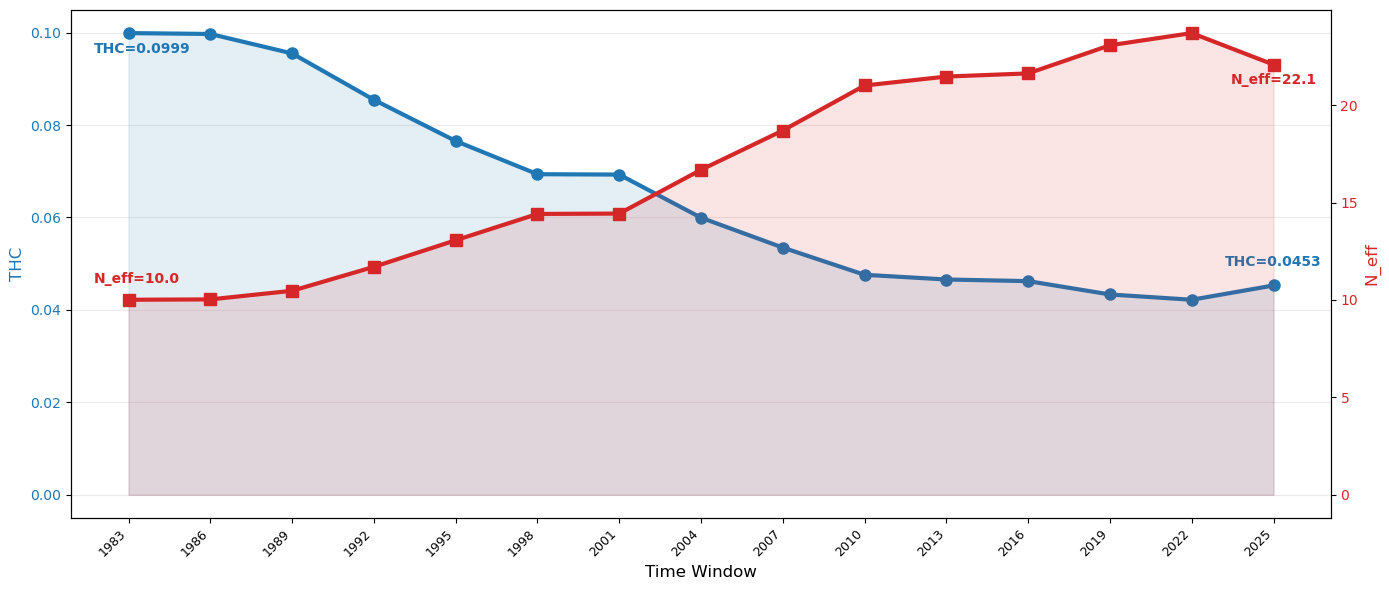


Key Numeric Summary
  THC (Concentration): 0.09989 → 0.04529  (change: -54.7%)

  * THC lowest (most dispersed): 2020-2022 (THC=0.04220)
  * Post-pandemic rebound: THC from 0.04220 back to 0.04529 (+7.3%)


In [9]:
# Layer 1 - Fig A: THC + N_eff Dual Axis Plot

years = df_ghn['year_label'].values
labels = df_ghn['label_short'].values

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

color_thc = '#1f77b4'
color_neff = '#d62728'

# THC (HHI) line on left axis
ax1.plot(years, df_ghn['THC'].values, color=color_thc, linewidth=3.0,
         marker='o', markersize=8, zorder=3)
ax1.fill_between(years, df_ghn['THC'].values, alpha=0.12, color=color_thc)
ax1.set_xlabel('Time Window', fontsize=12)
ax1.set_ylabel('THC', fontsize=12, color=color_thc)
ax1.tick_params(axis='y', labelcolor=color_thc)
ax1.set_xticks(years)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)

# N_eff line on right axis
ax2 = ax1.twinx()
ax2.plot(years, df_ghn['N_eff'].values, color=color_neff, linewidth=3.0,
         marker='s', markersize=8, zorder=3)
ax2.fill_between(years, df_ghn['N_eff'].values, alpha=0.12, color=color_neff)
ax2.set_ylabel('N_eff', fontsize=12, color=color_neff)
ax2.tick_params(axis='y', labelcolor=color_neff)

ax1.grid(axis='y', alpha=0.25)

# Annotate first and last values
first, last = 0, len(years) - 1

ax1.annotate(f'THC={df_ghn["THC"].values[first]:.4f}',
             (years[first], df_ghn["THC"].values[first]),
             textcoords="offset points", xytext=(-25, -14),
             fontsize=10, color=color_thc, fontweight='bold')
ax1.annotate(f'THC={df_ghn["THC"].values[last]:.4f}',
             (years[last], df_ghn["THC"].values[last]),
             textcoords="offset points", xytext=(0, 14),
             fontsize=10, color=color_thc, fontweight='bold', ha='center')

ax2.annotate(f'N_eff={df_ghn["N_eff"].values[first]:.1f}',
             (years[first], df_ghn["N_eff"].values[first]),
             textcoords="offset points", xytext=(-25, 12),
             fontsize=10, color=color_neff, fontweight='bold')
ax2.annotate(f'N_eff={df_ghn["N_eff"].values[last]:.1f}',
             (years[last], df_ghn["N_eff"].values[last]),
             textcoords="offset points", xytext=(0, -14),
             fontsize=10, color=color_neff, fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig('./fig_output/layer1_THC_single.png', dpi=200, bbox_inches='tight')
plt.show()

# Key numeric summary
print("\n" + "=" * 65)
print("Key Numeric Summary")
print("=" * 65)
thc_first = df_ghn['THC'].values[0]
thc_last = df_ghn['THC'].values[-1]
print(f"  THC (Concentration): {thc_first:.5f} → {thc_last:.5f}  "
      f"(change: {(thc_last - thc_first) / thc_first * 100:+.1f}%)")

# THC lowest point (most dispersed)
min_thc_idx = df_ghn['THC'].idxmin()
min_thc = df_ghn.loc[min_thc_idx, 'THC']
print(f"\n  * THC lowest (most dispersed): {df_ghn.loc[min_thc_idx, 'time_window']} "
      f"(THC={min_thc:.5f})")
print(f"  * Post-pandemic rebound: THC from {min_thc:.5f} back to {thc_last:.5f} "
      f"(+{(thc_last - min_thc) / min_thc * 100:.1f}%)")

### Layer 2: Continental / Regional Shift

Sliding windows: 45 windows (1981-2024 centered, 2025 backward)
First: 1980-1982  Last: 2023-2025


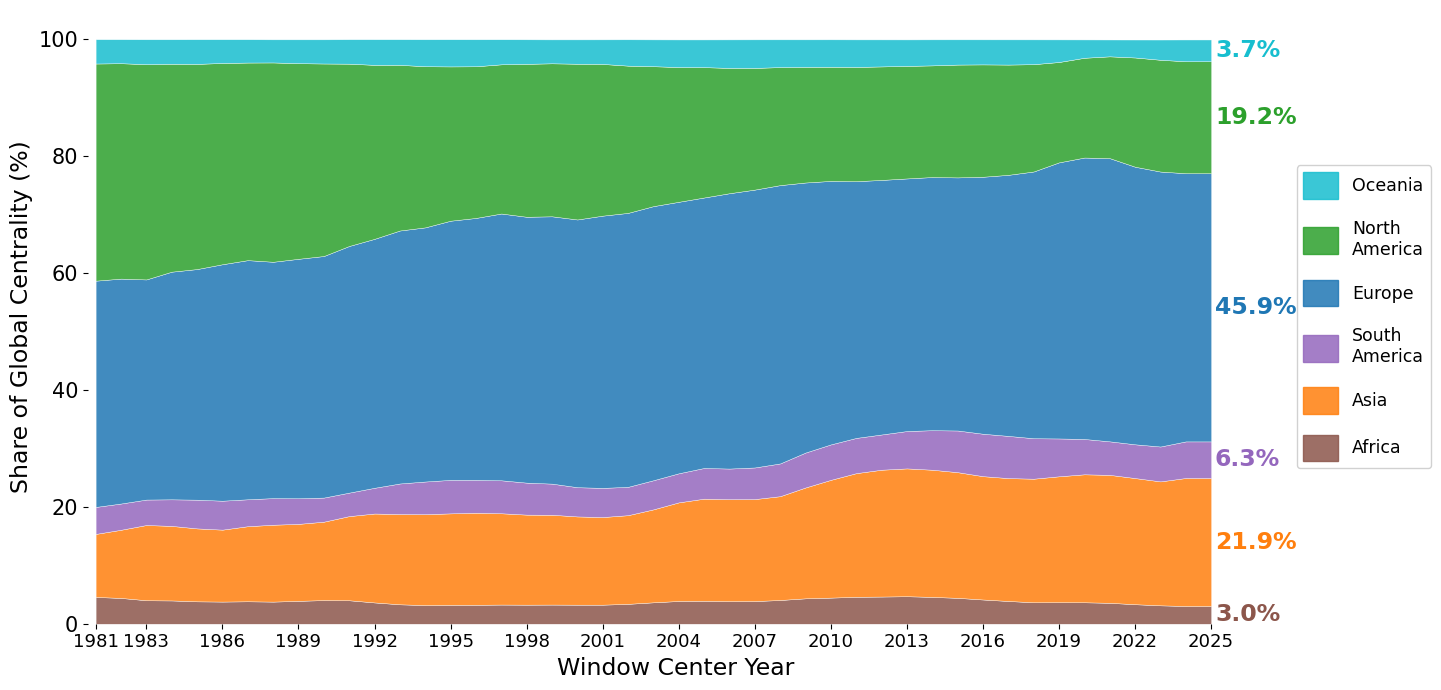


Sliding window chart saved → fig_output/layer2_continent_centrality_share_sliding.png


In [10]:
# Centered 3-year sliding windows from 1981 (1980-1982) to 2024 (2023-2025),
# with a final backward window 2023-2025 (no 2026 data)

window_defs = []
for yr in range(1981, 2025):  # centered windows for 1981..2024
    window_defs.append((yr - 1, yr + 1, str(yr)))
window_defs.append((2023, 2025, '2025'))  # final backward window

print(f"Sliding windows: {len(window_defs)} windows "
      f"(1981-2024 centered, 2025 backward)")
print(f"First: {window_defs[0][0]}-{window_defs[0][1]}  "
      f"Last: {window_defs[-1][0]}-{window_defs[-1][1]}")

# Aggregate centrality per window
sw_rows = []
for s, e, label in window_defs:
    sub = df_cent_yearly[(df_cent_yearly['year'] >= s) &
                         (df_cent_yearly['year'] <= e)]
    country_agg = sub.groupby(['country', 'continent'])['centrality_score'].sum().reset_index()
    total = country_agg['centrality_score'].sum()
    country_agg['share_pct'] = country_agg['centrality_score'] / total * 100
    cont_agg = country_agg.groupby('continent')['share_pct'].sum().reset_index()
    cont_agg['window_label'] = label
    sw_rows.append(cont_agg)

df_sw = pd.concat(sw_rows, ignore_index=True)
df_sw['window_label'] = df_sw['window_label'].astype(int)
sw_pivot = df_sw.pivot(index='window_label', columns='continent',
                       values='share_pct').fillna(0)

# Reorder stacking: place similar-sized continents (South America, Oceania)
# apart from each other so they are separated by larger continents
stack_order = ['Africa', 'Asia', 'South America', 'Europe', 'North America', 'Oceania']
categories = [c for c in stack_order if c in sw_pivot.columns]
sw_pivot = sw_pivot[categories]

x_labels = sw_pivot.index.tolist()
x_idx = np.arange(len(x_labels))

# X-ticks: roughly every 3 years
tick_positions = [i for i, yr in enumerate(x_labels)
                  if yr % 3 == 0 or i == 0 or i == len(x_labels) - 1]
tick_labels = [str(x_labels[i]) for i in tick_positions]

# Plot stacked area chart
fig, ax = plt.subplots(figsize=(14.5, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = [CONT_PALETTE[c] for c in categories]
values = [sw_pivot[c].values for c in categories]

ax.stackplot(x_idx, values, labels=categories, colors=colors,
             alpha=0.85, edgecolor='white', linewidth=0.3)

# Annotate final percentage values on the right side
cumulative = np.zeros(len(x_idx))
for i, cat in enumerate(categories):
    vals = sw_pivot[cat].values
    final_val = vals[-1]
    mid_y = cumulative[-1] + final_val / 2
    ax.text(x_idx[-1] + 0.15, mid_y, f'{final_val:.1f}%',
            fontsize=17, color=colors[i], fontweight='bold',
            va='center', ha='left')
    cumulative += vals

# Annotate Asia overtaking Europe
asia_vals = sw_pivot['Asia'].values if 'Asia' in sw_pivot.columns else []
eur_vals = sw_pivot['Europe'].values if 'Europe' in sw_pivot.columns else []
for i in range(len(x_idx)):
    if asia_vals[i] > eur_vals[i]:
        ax.annotate('Asia surpasses Europe', xy=(x_idx[i], asia_vals[i]),
                    xytext=(x_idx[i] - 5, asia_vals[i] + 12),
                    arrowprops=dict(arrowstyle='->', color='#ff7f0e', lw=1.5),
                    fontsize=15, color='#ff7f0e', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#fff8f0', alpha=0.9))
        break

# Legend: right side, vertical, with line-wrapped labels
labels_wrapped = [cat.replace(' ', '\n') for cat in categories[::-1]]
handles = [plt.Rectangle((0, 0), 1, 1, color=CONT_PALETTE[cat], alpha=0.85)
           for cat in categories[::-1]]
ax.legend(handles, labels_wrapped, loc='center left',
          bbox_to_anchor=(1.02, 0.5), fontsize=12.5,
          framealpha=0.9, ncol=1, labelspacing=1.2, handleheight=2.0)

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=13)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlim(-0.3, len(x_idx) + 1.1)
ax.set_ylim(0, 105)
ax.set_ylabel('Share of Global Centrality (%)', fontsize=17)
ax.set_xlabel('Window Center Year', fontsize=17)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('./fig_output/layer2_continent_centrality_share_sliding.png',
            dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSliding window chart saved → "
      f"fig_output/layer2_continent_centrality_share_sliding.png")

### Layer 3: Spotlight Rank Heatmap

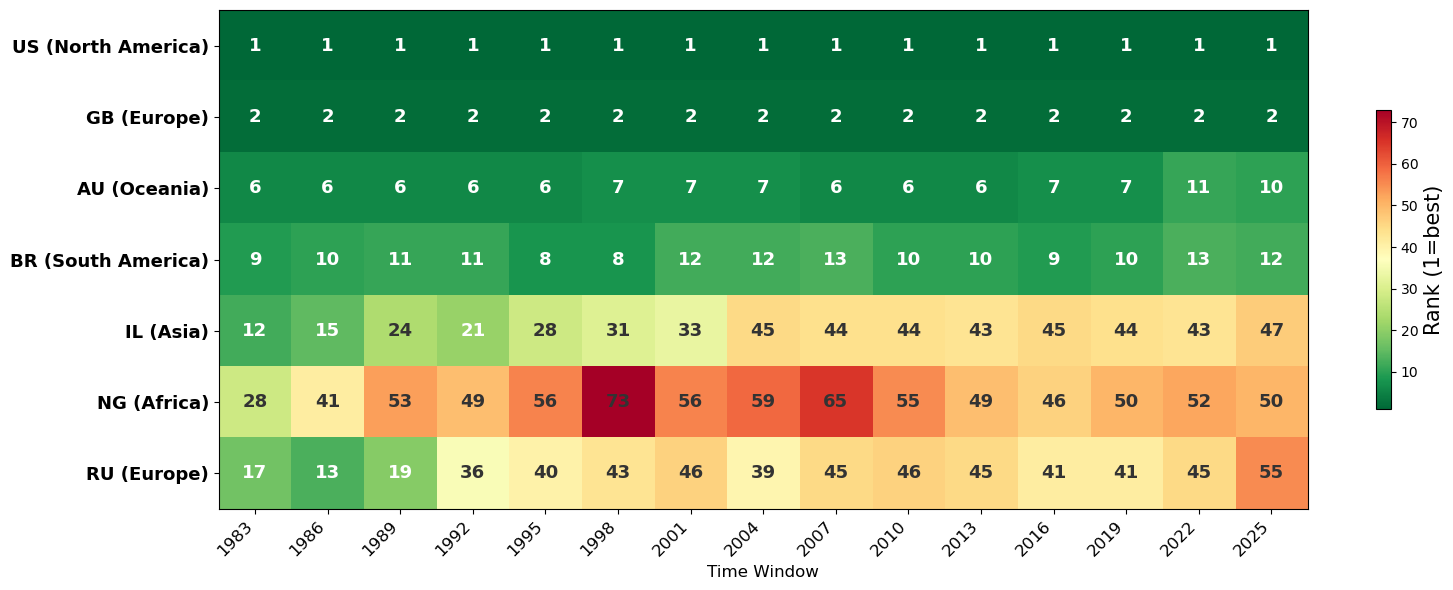


Spotlight Country Details
Country     Continent  1980s  Latest  ΔRank  Best  Worst  Std  Windows
     US North America      1       1      0     1      1  0.0       15
     GB        Europe      2       2      0     2      2  0.0       15
     AU       Oceania      6      10     -4     6     11  1.5       15
     BR South America      9      12     -3     8     13  1.6       15
     IL          Asia     12      47    -35    12     47 12.0       15
     NG        Africa     28      50    -22    28     73 10.2       15
     RU        Europe     17      55    -38    13     55 12.1       15


In [11]:
# Build spotlight country trajectory DataFrame
spot_rows = []
for c in SPOTLIGHT_COUNTRIES:
    if c not in pivot_df.index:
        continue
    traj = pivot_df.loc[c].dropna()
    first_r = int(traj.iloc[0])
    last_r = int(traj.iloc[-1])
    delta_r = first_r - last_r  # positive = improved
    max_r = int(traj.max())
    min_r = int(traj.min())
    volatility = traj.std()
    n_present = len(traj)
    cont = continent_map.get(c, '?')
    spot_rows.append({
        'Country': c, 'Continent': cont,
        '1980s': first_r, 'Latest': last_r, 'ΔRank': delta_r,
        'Best': min_r, 'Worst': max_r, 'Std': round(volatility, 1),
        'Windows': n_present
    })
spot_df = pd.DataFrame(spot_rows)

# Plot heatmap with continent annotations
traj_spot = pivot_df.loc[[c for c in SPOTLIGHT_COUNTRIES if c in pivot_df.index]]
traj_spot_filled = traj_spot.fillna(51).values.astype(int)
spot_tw_short = [tw.split('-')[1] if '-' in tw else tw for tw in traj_spot.columns]

vmax_spot = max(traj_spot_filled.max(), 51)

# Y-axis labels: country + continent
spot_yticks = [f'{c} ({continent_map.get(c, "?")})' for c in traj_spot.index]

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')

im = ax.imshow(traj_spot_filled, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=vmax_spot)
ax.set_yticks(range(len(traj_spot.index)))
ax.set_yticklabels(spot_yticks, fontsize=13, fontweight='bold')
ax.set_xticks(range(len(traj_spot.columns)))
ax.set_xticklabels(spot_tw_short, rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Time Window', fontsize=12)

for i in range(len(traj_spot.index)):
    for j in range(len(traj_spot.columns)):
        val = traj_spot_filled[i, j]
        color = 'white' if val <= vmax_spot * 0.3 else '#333333'
        ax.text(j, i, str(val), ha='center', va='center',
                fontsize=13, color=color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('Rank (1=best)', fontsize=15)

plt.tight_layout()
plt.savefig('./fig_output/layer3_spotlight.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "=" * 65)
print("Spotlight Country Details")
print("=" * 65)
print(spot_df.to_string(index=False))

### Talent Hubs: Dynamic Hub Set (N_eff = 1/THC)

In [12]:
# For each window, take the top N_eff countries by centrality score

neff_per_window = dict(zip(df_metrics['time_window'], df_metrics['N_eff']))

hub_rows = []
for tw in sorted(df_results['time_window'].unique()):
    n_eff = int(neff_per_window.get(tw, 0))
    if n_eff <= 0:
        continue
    window_data = df_results[df_results['time_window'] == tw]
    top_hubs = window_data.nsmallest(n_eff, 'rank')  # lowest rank = best
    hub_rows.append(top_hubs)

df_hubs = pd.concat(hub_rows, ignore_index=True)
df_hubs.to_csv('./data_output/talent_hubs_dynamic_set.csv', index=False)

# Pivot: country × time_window presence matrix
hub_pivot = df_hubs.pivot_table(index='country', columns='time_window',
                                values='centrality_score', aggfunc='first')
hub_present = hub_pivot.notna().astype(int)

# Hub tenure: how many windows each country appears
hub_tenure = hub_present.sum(axis=1).sort_values(ascending=False)

# Entry/Exit detection
hub_entry_exit = hub_present.diff(axis=1).fillna(0).astype(int)
# 1 = entered hub set, -1 = exited hub set, 0 = unchanged

# Core hubs: present in ALL windows
core_hubs = hub_tenure[hub_tenure == hub_present.shape[1]].index.tolist()

# Hub set size per window
hub_size = hub_present.sum(axis=0)

# Summary
time_windows_hubs = hub_pivot.columns.tolist()
print("=" * 70)
print("TALENT HUBS ANALYSIS — Dynamic Hub Set (N_eff = 1/THC)")
print("=" * 70)
print(f"\nHub set size evolution:")
for tw in time_windows_hubs:
    size = int(hub_size[tw])
    members = hub_pivot[tw].dropna().index.tolist()
    print(f"  {tw}: {size} hubs -> {', '.join(members)}")

# Entry/exit details per window
print(f"\nEntry/Exit details per window:")
for tw in time_windows_hubs[1:]:  # first window has no comparison
    entered = hub_entry_exit.index[hub_entry_exit[tw] == 1].tolist()
    exited = hub_entry_exit.index[hub_entry_exit[tw] == -1].tolist()
    if entered or exited:
        parts = []
        if entered:
            parts.append(f"Enter: {', '.join(entered)}")
        if exited:
            parts.append(f"Exit: {', '.join(exited)}")
        print(f"  {tw}: {'; '.join(parts)}")

print(f"\nCore hubs (present in ALL {hub_present.shape[1]} windows):")
print(f"  {', '.join(core_hubs)} ({len(core_hubs)} countries)")

print(f"\nHub tenure distribution (top 20):")
for c, tenure in hub_tenure.head(20).items():
    print(f"  {c:5s}: {int(tenure)}/{hub_present.shape[1]} windows")

TALENT HUBS ANALYSIS — Dynamic Hub Set (N_eff = 1/THC)

Hub set size evolution:
  1981-1983: 10 hubs -> AU, BR, CA, CH, DE, FR, GB, IT, JP, US
  1984-1986: 10 hubs -> AU, BR, CA, CH, DE, ES, FR, GB, IT, US
  1987-1989: 10 hubs -> AU, CA, CH, DE, ES, FR, GB, IT, JP, US
  1990-1992: 11 hubs -> AU, BR, CA, CH, DE, ES, FR, GB, IT, JP, US
  1993-1995: 13 hubs -> AU, BR, CA, CH, DE, ES, FR, GB, IT, JP, KR, NL, US
  1996-1998: 14 hubs -> AU, BR, CA, CH, DE, ES, FR, GB, IT, JP, KR, NL, SE, US
  1999-2001: 14 hubs -> AU, BR, CA, CH, DE, ES, FR, GB, IT, JP, MX, NL, PT, US
  2002-2004: 16 hubs -> AU, BR, CA, CH, CN, DE, ES, FR, GB, IT, JP, KR, NL, PT, SE, US
  2005-2007: 18 hubs -> AU, BR, CA, CH, CN, DE, ES, FR, GB, IN, IT, JP, KR, MX, NL, PT, SE, US
  2008-2010: 21 hubs -> AU, BE, BR, CA, CH, CN, CO, DE, ES, FR, GB, IN, IT, JP, KR, MX, MY, NL, PT, SE, US
  2011-2013: 21 hubs -> AU, BE, BR, CA, CH, CN, DE, ES, FR, GB, IN, IT, JP, KR, MY, NL, PT, SA, SE, TR, US
  2014-2016: 21 hubs -> AU, BE, BR,

### Talent Hubs: Membership Timeline Heatmap

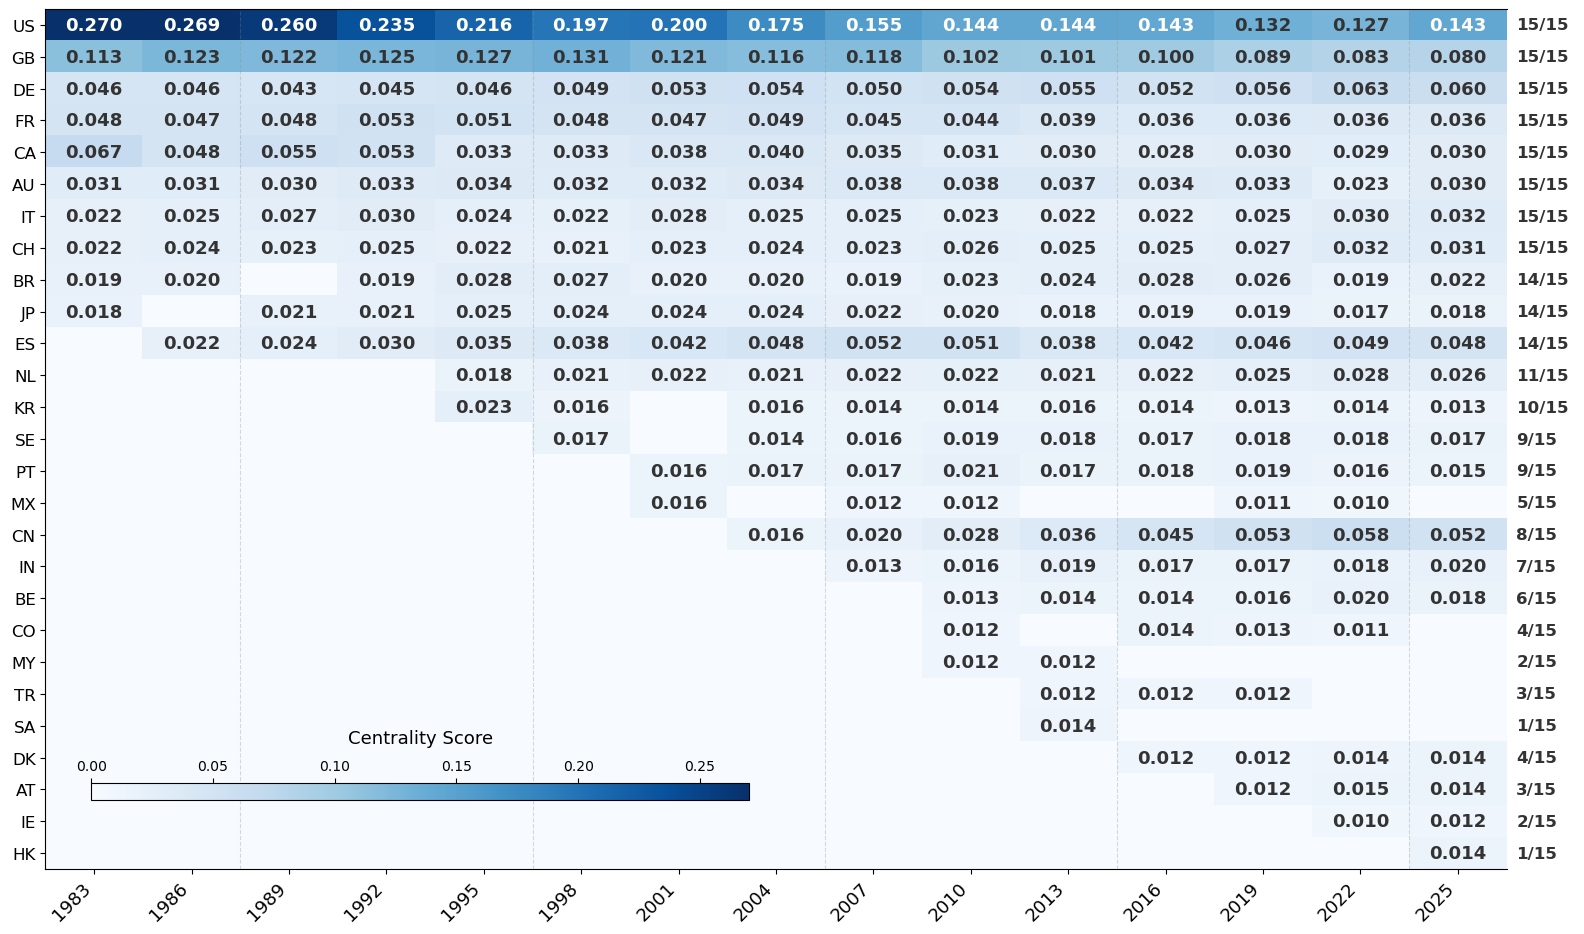

In [13]:
# Sort countries: by first appearance window → tenure → mean centrality
country_order = hub_tenure.index.tolist()
hub_first_window = hub_present.idxmax(axis=1)
hub_mean_c = hub_pivot.mean(axis=1)
country_order = sorted(country_order, key=lambda c: (
    hub_first_window[c], -hub_tenure[c], -hub_mean_c[c]
))

hubs_tw_short = [tw.split('-')[1] for tw in time_windows_hubs]
score_matrix = hub_pivot.loc[country_order].fillna(0).values

fig, ax = plt.subplots(figsize=(16, max(8, len(country_order) * 0.35)))
fig.patch.set_facecolor('white')

cmap = plt.cm.Blues
im = ax.imshow(score_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=score_matrix.max())

# Annotate hub membership cells with centrality value (3 decimal places)
for i, country in enumerate(country_order):
    for j, tw in enumerate(time_windows_hubs):
        val = score_matrix[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=13,
                    color='white' if val > score_matrix.max() * 0.5 else '#333333',
                    fontweight='bold')

# Right margin: tenure count (shifted left for compactness)
for i, country in enumerate(country_order):
    tenure = hub_tenure[country]
    ax.text(len(time_windows_hubs) - 0.4, i, f'{int(tenure)}/{hub_present.shape[1]}',
            va='center', fontsize=12, fontweight='bold', color='#333333')

ax.set_xticks(range(len(time_windows_hubs)))
ax.set_xticklabels(hubs_tw_short, rotation=45, ha='right', fontsize=13)
ax.set_yticks(range(len(country_order)))
ax.set_yticklabels(country_order, fontsize=12)
ax.set_xlim(-0.5, len(time_windows_hubs) + 0.2)

# Add vertical lines to separate decades
decade_windows = [2, 5, 8, 11, 14]  # indices for ~1984, ~1993, ~2002, ~2011, ~2020
for j in decade_windows:
    if j < len(time_windows_hubs):
        ax.axvline(x=j - 0.5, color='#888888', linestyle='--', alpha=0.3, linewidth=0.8)

# Horizontal colorbar at bottom-left
cax = ax.inset_axes([0.03, 0.08, 0.43, 0.02])
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
cbar.set_label('Centrality Score', fontsize=13, labelpad=12)
cax.xaxis.set_ticks_position('top')
cax.xaxis.set_label_position('top')

# Hide right spine, trim top/bottom spines to heatmap edge
ax.spines['right'].set_visible(False)
matrix_right_edge = len(time_windows_hubs) - 0.5
ax.spines['top'].set_bounds(-0.5, matrix_right_edge)
ax.spines['bottom'].set_bounds(-0.5, matrix_right_edge)

plt.tight_layout()
plt.savefig('./fig_output/talenthubs_membership_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

# Appendix: Data Coverage & Completeness

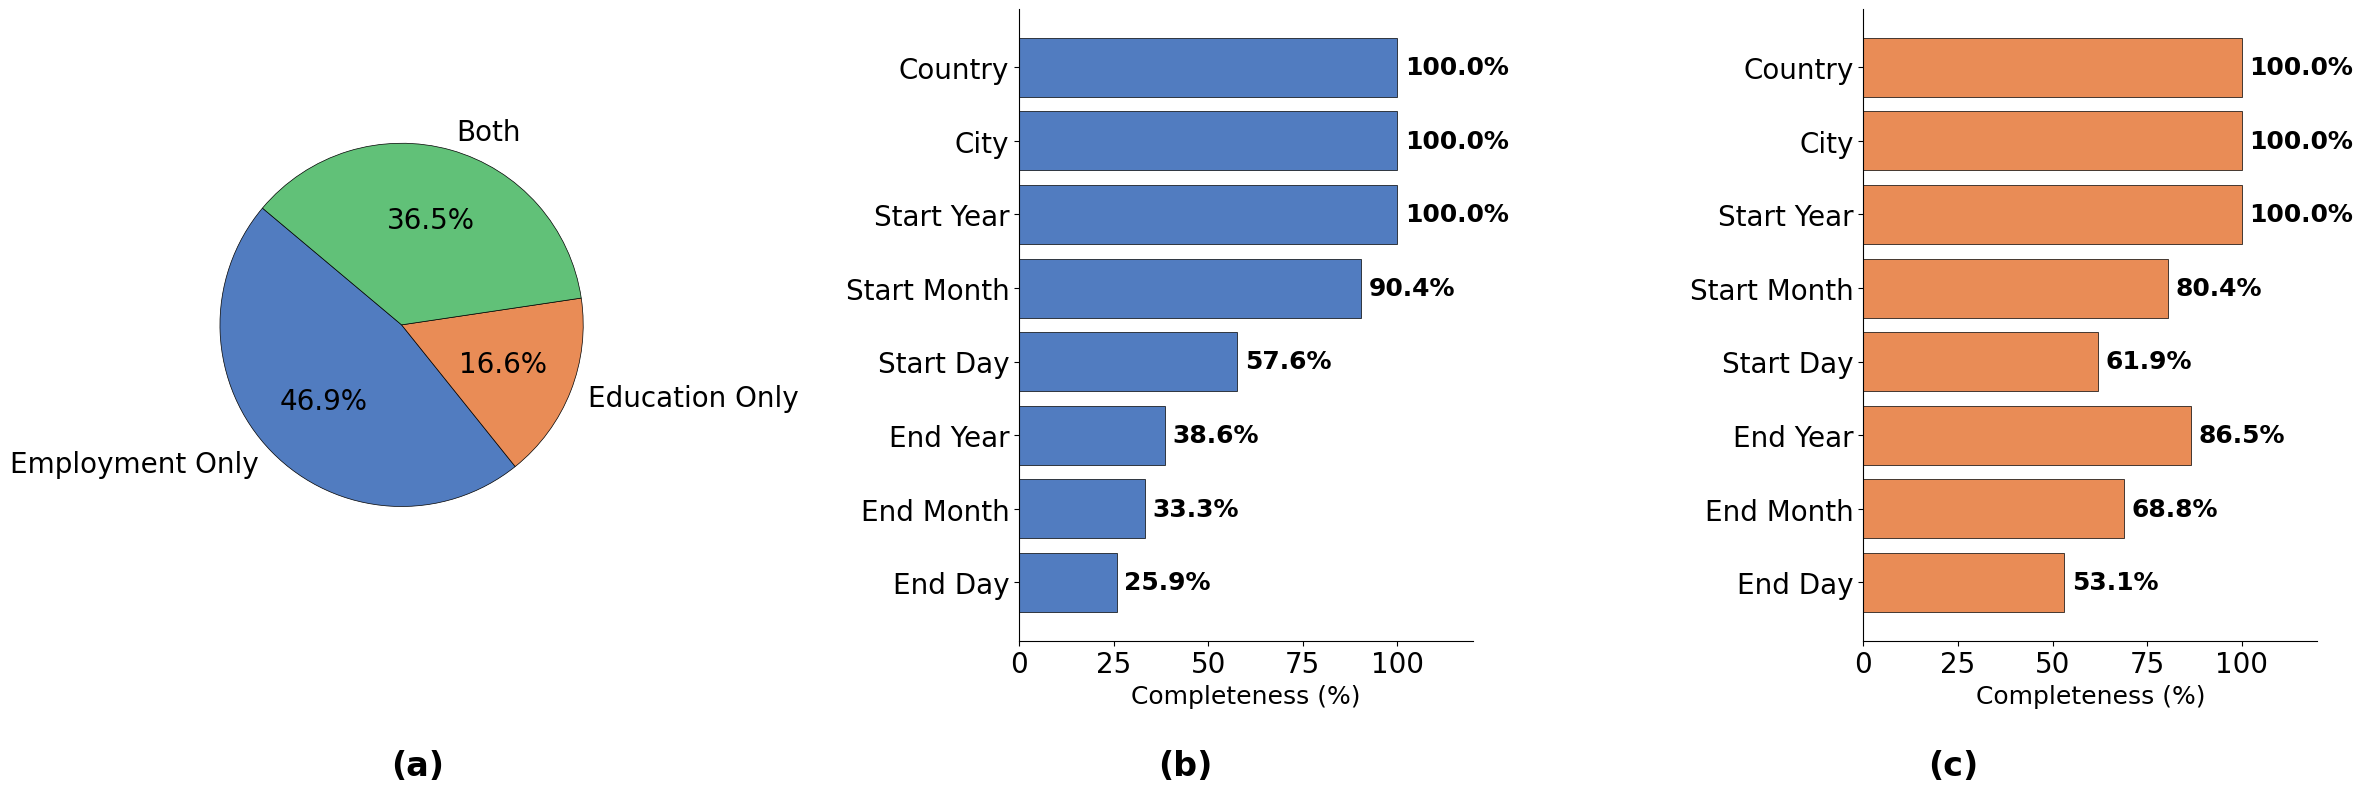

In [15]:
# Data coverage: Employment vs Education records

coverage_labels = ['Employment Only', 'Education Only', 'Both']
coverage_sizes = [3313844, 1173646, 2583085]
colors_pie = ["#517CC0", "#E98C56", "#61C178"]

colors_bar = ["#517CC0", "#E98C56"]

emp_attrs = ['Country', 'City', 'Start Year', 'Start Month', 'Start Day',
             'End Year', 'End Month', 'End Day']
emp_comp = [100.0, 100.0, 100.0, 90.36, 57.64, 38.57, 33.30, 25.88]

edu_attrs = ['Country', 'City', 'Start Year', 'Start Month', 'Start Day',
             'End Year', 'End Month', 'End Day']
edu_comp = [100.0, 100.0, 100.0, 80.43, 61.94, 86.46, 68.84, 53.07]

fig, axs = plt.subplots(1, 3, figsize=(24, 8.5))

# (a) Coverage pie chart
axs[0].pie(coverage_sizes, labels=coverage_labels, autopct='%1.1f%%',
           startangle=140, colors=colors_pie,
           wedgeprops={'edgecolor': 'black', 'linewidth': 0.5},
           textprops={'fontsize': 20})

# (b) Employment attribute completeness
y_pos_emp = np.arange(len(emp_attrs))
axs[1].barh(y_pos_emp, emp_comp[::-1], color=colors_bar[0],
            edgecolor='black', linewidth=0.5)
axs[1].set_yticks(y_pos_emp)
axs[1].set_yticklabels(emp_attrs[::-1])
axs[1].set_xlabel('Completeness (%)', fontsize=18)
axs[1].tick_params(axis='both', labelsize=20)
axs[1].set_xlim(0, 120)
for i, v in enumerate(emp_comp[::-1]):
    axs[1].text(v + 2, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=18)
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

# (c) Education attribute completeness
y_pos_edu = np.arange(len(edu_attrs))
axs[2].barh(y_pos_edu, edu_comp[::-1], color=colors_bar[1],
            edgecolor='black', linewidth=0.5)
axs[2].set_yticks(y_pos_edu)
axs[2].set_yticklabels(edu_attrs[::-1])
axs[2].set_xlabel('Completeness (%)', fontsize=18)
axs[2].tick_params(axis='both', labelsize=20)
axs[2].set_xlim(0, 120)
for i, v in enumerate(edu_comp[::-1]):
    axs[2].text(v + 2, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=18)
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)

# Align subplot labels using absolute positioning
fig.text(0.18, 0.05, '(a)', size=24, ha='center', fontweight='bold')
fig.text(0.50, 0.05, '(b)', size=24, ha='center', fontweight='bold')
fig.text(0.82, 0.05, '(c)', size=24, ha='center', fontweight='bold')

plt.savefig('./fig_output/ORCID_overview.png', dpi=200, bbox_inches='tight')
plt.tight_layout(rect=[0, 0.08, 1, 1], pad=3.0, w_pad=4.0)
plt.show()